## In this notebook, we partition the _Corpus Nummorum_ data and train/validate/test our computer-vision model

Plan of attack
* Creating train/validate/test split
* Training and validation with ImageNet 21k model
* Fine-tuning
* Testing
* Saving model checkpoint as .pth file

In [ ]:
!pip install iterative-stratification -q

In [ ]:
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

group_df = (
    df.groupby("coin_id")[sample_motifs]
    .max()
    .reset_index()
)

X = group_df["coin_id"].values
Y = group_df[sample_motifs].values

splitter = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

trainval_idx, test_idx = next(splitter.split(X, Y))

trainval_groups = group_df.iloc[trainval_idx].copy()
test_groups = group_df.iloc[test_idx].copy()

splitter2 = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

X_tv = trainval_groups["coin_id"].values
Y_tv = trainval_groups[sample_motifs].values

train_idx, val_idx = next(splitter2.split(X_tv, Y_tv))

train_groups = set(trainval_groups.iloc[train_idx]["coin_id"])
val_groups = set(trainval_groups.iloc[val_idx]["coin_id"])
test_groups = set(test_groups["coin_id"])

df["split"] = "none"
df.loc[df["coin_id"].isin(train_groups), "split"] = "train"
df.loc[df["coin_id"].isin(val_groups), "split"] = "val"
df.loc[df["coin_id"].isin(test_groups), "split"] = "test"

df["split"].value_counts()

,count
split,
train,34906
test,10898
val,8685


In [ ]:
df.groupby("split")[sample_motifs].sum()

,eagle,throne,snake,bull,horse,star,head
split,,,,,,,
test,317.0,281.0,479.0,265.0,493.0,122.0,3612.0
train,999.0,901.0,1538.0,861.0,1565.0,381.0,11472.0
val,248.0,222.0,384.0,216.0,387.0,94.0,2894.0


In [ ]:
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader

class CoinMotifDataset(Dataset):
    def __init__(self, frame, motif_cols, transform=None):
        self.frame = frame.reset_index(drop=True)
        self.motif_cols = motif_cols
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]

        img = Image.open(row["image_path"]).convert("RGB")

        if self.transform:
            img = self.transform(img)

        y = torch.tensor(row[self.motif_cols].values.astype("float32"))

        return img, y

In [ ]:
# import timm
# from timm.data import resolve_model_data_config, create_transform

# sample_motifs.append("head")
# # sample_motifs.append("spear")

# num_motifs = len(sample_motifs)

# model = timm.create_model(
#     "vit_base_patch16_224.augreg_in21k",
#     pretrained=True,
#     num_classes=num_motifs
# )

# data_config = resolve_model_data_config(model)

# train_tfms = create_transform(**data_config, is_training=True)
# eval_tfms = create_transform(**data_config, is_training=False)

In [ ]:
# df

In [ ]:
# from pathlib import Path

# src = Path(image_path)  # your Drive folder containing motif/image folders
# tar_path = Path("/content/drive/MyDrive/coin_images.tar")

# print("source:", src)
# print("tar:", tar_path)

# !tar -czf "$tar_path" -C "$src" .



In [ ]:
local_root = Path("/content/coin_images")
local_root.mkdir(parents=True, exist_ok=True)

In [ ]:
!tar -xf "$tar_path" -C "$local_root"

tar: : Cannot open: No such file or directory
tar: Error is not recoverable: exiting now


In [ ]:
!mkdir -p /content/coin_images
!tar -xf /content/drive/MyDrive/coin_images.tar -C /content/coin_images

In [ ]:
old_root = str(Path(image_path))
new_root = str(local_root)

df["image_path"] = df["image_path"].str.replace(
    old_root,
    new_root,
    regex=False
)

long_df["image_path_in_motif_folder"] = long_df["image_path_in_motif_folder"].str.replace(
    old_root,
    new_root,
    regex=False
)

In [ ]:

df["image_exists"] = df["image_path"].apply(lambda p: Path(p).exists())
df["image_exists"].value_counts()

,count
image_exists,
True,54489


In [ ]:
df

,image_id,filename,coin_id,type_id,side,image_path,bull,eagle,head,horse,snake,star,throne,split,image_exists
0,10001_obv,CN_type_10733_MK_18234616_cn_coin_10001_o_obv.jpg,10001,10733,obv,/content/coin_images/bust/CN_type_10733_MK_182...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,train,True
1,10001_rev,CN_type_10733_MK_18234616_cn_coin_10001_o_rev.jpg,10001,10733,rev,/content/coin_images/foot/CN_type_10733_MK_182...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,train,True
2,10009_obv,CN_type_8658_MK_18235374_cn_coin_10009_o_obv.jpg,10009,8658,obv,/content/coin_images/bust/CN_type_8658_MK_1823...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,train,True
3,10009_rev,CN_type_8658_MK_18235374_cn_coin_10009_o_rev.jpg,10009,8658,rev,/content/coin_images/corn/CN_type_8658_MK_1823...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,train,True
4,1000_obv,CN_type_8499_cn_coin_1000_p_obv.jpg,1000,8499,obv,/content/coin_images/bust/CN_type_8499_cn_coin...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,test,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54484,9993_rev,CN_type_8281_MK_18208282_cn_coin_9993_o_rev.jpg,9993,8281,rev,/content/coin_images/herm/CN_type_8281_MK_1820...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,val,True
54485,999_obv,CN_type_8499_cn_coin_999_p_obv.jpg,999,8499,obv,/content/coin_images/bust/CN_type_8499_cn_coin...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,val,True
54486,999_rev,CN_type_8499_cn_coin_999_p_rev.jpg,999,8499,rev,/content/coin_images/amphora/CN_type_8499_cn_c...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,val,True
54487,99_obv,CN_type_3987_cn_coin_99_p_obv.jpg,99,3987,obv,/content/coin_images/bull/CN_type_3987_cn_coin...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,test,True


In [ ]:
import timm
from timm.data import resolve_model_data_config, create_transform

# sample_motifs.append("head")
# sample_motifs.append("spear")

num_motifs = len(sample_motifs)

model = timm.create_model(
    "vit_base_patch16_224.augreg_in21k",
    pretrained=True,
    num_classes=num_motifs
)

data_config = resolve_model_data_config(model)

train_tfms = create_transform(**data_config, is_training=True)
eval_tfms = create_transform(**data_config, is_training=False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/410M [00:00<?, ?B/s]

In [ ]:
train_df = df[df["split"] == "train"].copy()
val_df = df[df["split"] == "val"].copy()
test_df = df[df["split"] == "test"].copy()

train_ds = CoinMotifDataset(train_df, sample_motifs, train_tfms)
val_ds = CoinMotifDataset(val_df, sample_motifs, eval_tfms)
test_ds = CoinMotifDataset(test_df, sample_motifs, eval_tfms)

Preparing and training the model

In [ ]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

test_loader = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

In [ ]:
from tqdm.auto import tqdm
import torch
import numpy as np
from sklearn.metrics import average_precision_score

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

train_labels = torch.tensor(train_df[sample_motifs].values.astype("float32"))

pos = train_labels.sum(dim=0)
neg = len(train_labels) - pos
pos_weight = (neg / pos.clamp(min=1)).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

In [ ]:
from tqdm.auto import tqdm
import copy
import numpy as np
import torch
from sklearn.metrics import average_precision_score

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

def count_trainable(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"Trainable params: {trainable:,} / {total:,} ({100 * trainable / total:.3f}%)")

def macro_ap(y_true, y_prob, motif_cols):
    scores = []
    for j, motif in enumerate(motif_cols):
        if y_true[:, j].sum() > 0:
            scores.append(average_precision_score(y_true[:, j], y_prob[:, j]))
    return float(np.mean(scores)) if scores else np.nan

def train_one_epoch(model, loader, optimizer, criterion, device, epoch, phase):
    model.train()
    total_loss = 0.0

    pbar = tqdm(loader, desc=f"{phase} epoch {epoch}", leave=False)

    for imgs, y in pbar:
        imgs = imgs.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(imgs)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    return total_loss / len(loader.dataset)

@torch.no_grad()
def predict(model, loader, device, desc="Validate"):
    model.eval()

    probs_all = []
    y_all = []

    pbar = tqdm(loader, desc=desc, leave=False)

    for imgs, y in pbar:
        imgs = imgs.to(device, non_blocking=True)

        logits = model(imgs)
        probs = torch.sigmoid(logits).cpu()

        probs_all.append(probs)
        y_all.append(y.cpu())

    return torch.cat(probs_all).numpy(), torch.cat(y_all).numpy()

def run_training_phase(model, train_loader, val_loader, optimizer, criterion, device,
                       num_epochs, phase, best_score=-np.inf, best_state=None):
    for epoch in tqdm(range(1, num_epochs + 1), desc=phase):
        train_loss = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device,
            epoch=epoch,
            phase=phase,
        )

        val_probs, val_y = predict(
            model=model,
            loader=val_loader,
            device=device,
            desc=f"{phase} validation {epoch}",
        )

        val_ap = macro_ap(val_y, val_probs, sample_motifs)

        print(f"{phase} epoch {epoch}: train_loss={train_loss:.4f}, val_macro_AP={val_ap:.4f}")

        if val_ap > best_score:
            best_score = val_ap
            best_state = copy.deepcopy(model.state_dict())
            print(f"  New best val_macro_AP: {best_score:.4f}")

    return best_score, best_state

In [ ]:
# Phase 1: train only the new classifier head
for p in model.parameters():
    p.requires_grad = False

for p in model.get_classifier().parameters():
    p.requires_grad = True

count_trainable(model)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4,
)

best_score = -np.inf
best_state = None

best_score, best_state = run_training_phase(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    num_epochs=5,
    phase="Head training",
    best_score=best_score,
    best_state=best_state,
)

Trainable params: 5,383 / 85,804,039 (0.006%)


Head training:   0%|          | 0/5 [00:00<?, ?it/s]

Head training epoch 1:   0%|          | 0/1091 [00:00<?, ?it/s]

Head training validation 1:   0%|          | 0/272 [00:00<?, ?it/s]

Head training epoch 1: train_loss=1.1546, val_macro_AP=0.2601
  New best val_macro_AP: 0.2601


...

Head training validation 4:   0%|          | 0/272 [00:00<?, ?it/s]

Head training epoch 4: train_loss=0.8857, val_macro_AP=0.3815
  New best val_macro_AP: 0.3815


Head training epoch 5:   0%|          | 0/1091 [00:00<?, ?it/s]

Head training validation 5:   0%|          | 0/272 [00:00<?, ?it/s]

Head training epoch 5: train_loss=0.8649, val_macro_AP=0.3994
  New best val_macro_AP: 0.3994


In [ ]:
# Phase 2: fine-tune last 4 ViT blocks + final norm + classifier head
for p in model.parameters():
    p.requires_grad = False

for p in model.blocks[-4:].parameters():
    p.requires_grad = True

for p in model.norm.parameters():
    p.requires_grad = True

for p in model.get_classifier().parameters():
    p.requires_grad = True

count_trainable(model)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr= 1e-5,
    weight_decay=1e-4,
)

best_score, best_state = run_training_phase(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    num_epochs=10,
    phase="Fine-tuning",
    best_score=best_score,
    best_state=best_state,
)

model.load_state_dict(best_state)
print(f"Best validation macro AP: {best_score:.4f}")

Trainable params: 28,358,407 / 85,804,039 (33.050%)


Fine-tuning:   0%|          | 0/10 [00:00<?, ?it/s]

Fine-tuning epoch 1:   0%|          | 0/1091 [00:00<?, ?it/s]

Fine-tuning validation 1:   0%|          | 0/272 [00:00<?, ?it/s]

Fine-tuning epoch 1: train_loss=0.7891, val_macro_AP=0.5682
  New best val_macro_AP: 0.5682


...

Fine-tuning validation 9:   0%|          | 0/272 [00:00<?, ?it/s]

Fine-tuning epoch 9: train_loss=0.3664, val_macro_AP=0.7928


Fine-tuning epoch 10:   0%|          | 0/1091 [00:00<?, ?it/s]

Fine-tuning validation 10:   0%|          | 0/272 [00:00<?, ?it/s]

Fine-tuning epoch 10: train_loss=0.3515, val_macro_AP=0.8183
  New best val_macro_AP: 0.8183
Best validation macro AP: 0.8183


In [ ]:
test_probs, test_y = predict(
    model=model,
    loader=test_loader,
    device=device,
    desc="Test",
)

for j, motif in enumerate(sample_motifs):
    positives = int(test_y[:, j].sum())

    if positives > 0:
        ap = average_precision_score(test_y[:, j], test_probs[:, j])
        print(f"{motif}: AP={ap:.4f}, positives={positives}")
    else:
        print(f"{motif}: AP=undefined, positives=0")

Test:   0%|          | 0/341 [00:00<?, ?it/s]

eagle: AP=0.7564, positives=317
throne: AP=0.8305, positives=281
snake: AP=0.7304, positives=479
bull: AP=0.8280, positives=265
horse: AP=0.8858, positives=493
star: AP=0.8288, positives=122
head: AP=0.9110, positives=3612


Now we survey our handiwork and verify that our model is picking up on the right things

In [ ]:
@torch.no_grad()
def show_top_predictions(model, dataset, motif_cols, device, n=12, top_k=3):
    model.eval()

    indices = np.random.choice(len(dataset), size=min(n, len(dataset)), replace=False)

    num_cols = 4
    num_rows = int(np.ceil(len(indices) / num_cols))

    plt.figure(figsize=(4.5 * num_cols, 4.8 * num_rows))

    for plot_i, idx in enumerate(indices):
        img_tensor, y_true = dataset[idx]

        x = img_tensor.unsqueeze(0).to(device)
        logits = model(x)
        probs = torch.sigmoid(logits).squeeze(0).cpu().numpy()

        y_true = y_true.numpy()

        true_labels = [motif_cols[j] for j, v in enumerate(y_true) if v == 1]

        top_idxs = np.argsort(probs)[::-1][:top_k]
        top_preds = [f"{motif_cols[j]}:{probs[j]:.2f}" for j in top_idxs]

        img = img_tensor.detach().cpu().permute(1, 2, 0).numpy()

        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = img * std + mean
        img = np.clip(img, 0, 1)

        plt.subplot(num_rows, num_cols, plot_i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(
            "True: " + (", ".join(true_labels) if true_labels else "none") +
            "\nTop: " + ", ".join(top_preds),
            fontsize=9,
        )

    # plt.tight_layout()
    plt.show()

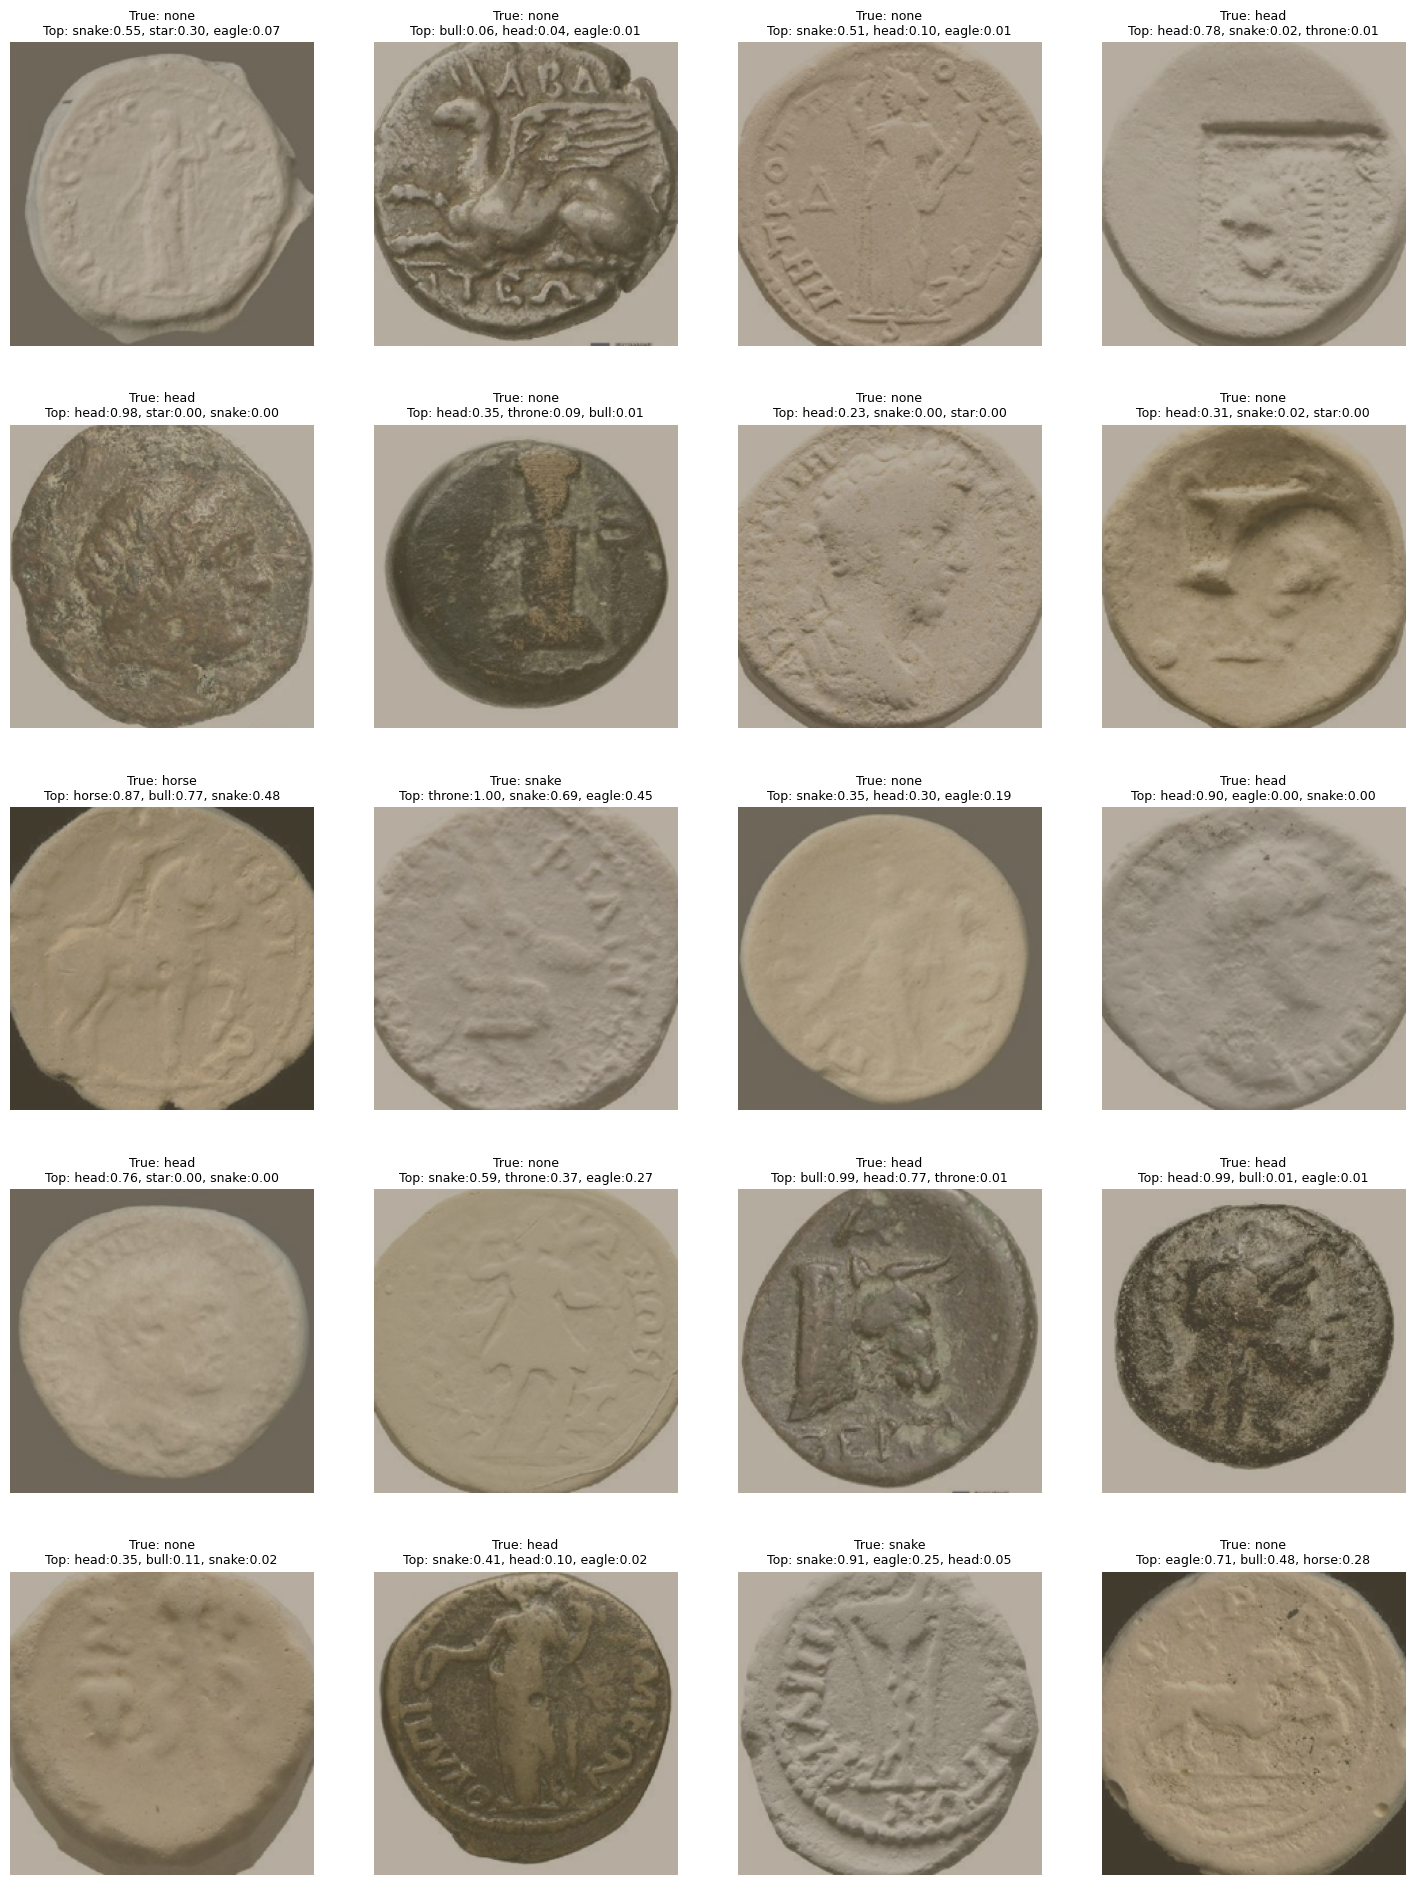

In [ ]:
show_top_predictions(
    model=model,
    dataset=test_ds,
    motif_cols=sample_motifs,
    device=device,
    n=20,
    top_k=3,
)

Saves the model checkpoint as a .pth file

In [ ]:
from pathlib import Path
import torch

save_path = Path("/content/drive/MyDrive/coin_motif_vit_checkpoint.pth")

checkpoint = {
    "model_name": "vit_base_patch16_224.augreg_in21k",
    "model_state_dict": model.state_dict(),
    "sample_motifs": sample_motifs,
    "thresholds": thresholds if "thresholds" in globals() else None,
    "best_score": best_score if "best_score" in globals() else None,
}

torch.save(checkpoint, save_path)

print("saved to:", save_path)

saved to: /content/drive/MyDrive/coin_motif_vit_checkpoint.pth


In [ ]:
# import torch
# import timm

# checkpoint = torch.load(
#     "/content/drive/MyDrive/coin_motif_vit_checkpoint.pth",
#     map_location="cuda" if torch.cuda.is_available() else "cpu"
# )

# sample_motifs = checkpoint["sample_motifs"]
# num_motifs = len(sample_motifs)

# model = timm.create_model(
#     checkpoint["model_name"],
#     pretrained=False,
#     num_classes=num_motifs
# )

# model.load_state_dict(checkpoint["model_state_dict"])

# device = "cuda" if torch.cuda.is_available() else "cpu"
# model = model.to(device)
# model.eval()

# thresholds = checkpoint.get("thresholds")

In [ ]:
# with torch.no_grad():
#     logits = model(imgs.to(device))
#     probs = torch.sigmoid(logits)